<a href="https://colab.research.google.com/github/Gayathrini11/Deep-learning/blob/main/DL_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1, l2


In [2]:
X, y = make_regression(
    n_samples=100,
    n_features=100,
    n_informative=10,
    noise=10,
    random_state=42
)


In [3]:
print(X.shape)
print(y.shape)
df = pd.DataFrame(X)
df.head()


(100, 100)
(100,)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.060230,-1.191303,0.068563,-0.245388,-1.415371,1.886186,-0.072829,-0.889514,0.521942,-1.918771,...,-0.192361,-0.034712,0.827183,0.482472,0.963376,-1.550663,-1.607483,0.184634,0.856399,-1.514847
1,-0.223026,0.953009,0.176762,0.533695,-0.116571,0.734106,-0.614144,-0.391025,0.332760,-0.879644,...,-0.152855,1.762980,-0.913459,0.826422,0.667065,-0.366342,-0.145349,0.347397,0.891841,-0.444946
2,-0.769142,0.262561,-0.973546,1.422748,-0.675178,0.001205,-0.147780,0.965397,-0.327895,-1.607560,...,0.829475,-0.264515,-0.316073,-2.296181,0.265362,0.807123,-0.524088,0.152355,0.300474,1.452468
3,1.667224,1.186735,-2.025808,0.231446,0.185176,-0.772659,-0.211667,-0.215668,0.228996,1.183494,...,0.735622,-1.656623,1.355443,0.876456,0.665417,-0.417910,-1.668599,1.058729,-2.487809,-0.288039
4,1.991553,0.018819,1.346226,-0.454548,0.491429,0.682069,0.664927,-0.091400,-0.387700,-0.674934,...,-0.550115,0.840734,-1.284584,-0.064184,0.175287,0.466545,0.140983,1.588627,-0.213457,-1.597599


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
baseline = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dense(32, activation='relu'),
    Dense(1)
])

baseline.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_base = baseline.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 22139.2402 - mae: 112.9286 - val_loss: 14133.8652 - val_mae: 98.9866
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 22089.1641 - mae: 112.7869 - val_loss: 14130.0566 - val_mae: 98.9795
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 22042.6602 - mae: 112.6658 - val_loss: 14125.7441 - val_mae: 98.9700
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 22002.0781 - mae: 112.5545 - val_loss: 14124.0879 - val_mae: 98.9711
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 21957.1016 - mae: 112.4333 - val_loss: 14119.2832 - val_mae: 98.9623
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 21904.7402 - mae: 112.2970 - val_loss: 14115.3994 - val_mae: 98.9580
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 21854.1875 - mae: 112.1627 - val_loss: 14110.8535 - val_mae: 98.9528
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 21800.3477 - mae: 112.0237 - val_loss: 14106.5049 - 

In [8]:
pred_base = baseline.predict(X_test)
print("Baseline MSE:",      mean_squared_error(y_test, pred_base))
print("Baseline MAE:",      mean_absolute_error(y_test, pred_base))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Baseline MSE: 10266.132670201321
Baseline MAE: 88.95327920769932


In [11]:
model_l1 = Sequential([
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l1(0.01),
        input_shape=(100,)
    ),
    Dense(
        32,
        activation='relu',
        kernel_regularizer=l1(0.01)
    ),
    Dense(1)
])

model_l1.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_l1 = model_l1.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 22101.8652 - mae: 112.8726 - val_loss: 14033.8848 - val_mae: 98.4526
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 22016.2109 - mae: 112.6586 - val_loss: 14029.8008 - val_mae: 98.4375
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 21946.3359 - mae: 112.4697 - val_loss: 14022.5967 - val_mae: 98.4089
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 21873.7617 - mae: 112.2843 - val_loss: 14015.8682 - val_mae: 98.3845
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 21802.6992 - mae: 112.0923 - val_loss: 14009.8965 - val_mae: 98.3651
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 21721.5742 - mae: 111.8801 - val_loss: 14002.9629 - val_mae: 98.3424
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 21641.2305 - mae: 111.6613 - val_loss: 13994.7002 - val_mae: 98.3123
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 21551.1270 - mae: 111.4162 - val_loss: 13989.6777 - 

In [12]:
pred_l1 = model_l1.predict(X_test)
print("L1 MSE:",      mean_squared_error(y_test, pred_l1))
print("L1 MAE:",      mean_absolute_error(y_test, pred_l1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
L1 MSE: 10546.480266367707
L1 MAE: 83.948780741572


In [13]:
model_l2 = Sequential([
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.01),
        input_shape=(100,)
    ),
    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.01)
    ),
    Dense(1)
])

model_l2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 22106.7422 - mae: 112.8360 - val_loss: 14072.2461 - val_mae: 98.6445
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 22050.7812 - mae: 112.6686 - val_loss: 14065.0605 - val_mae: 98.6217
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 21986.3516 - mae: 112.4857 - val_loss: 14060.0488 - val_mae: 98.6098
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 21930.7266 - mae: 112.3312 - val_loss: 14054.1318 - val_mae: 98.5934
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 21873.2012 - mae: 112.1672 - val_loss: 14048.1758 - val_mae: 98.5763
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 21812.5176 - mae: 112.0026 - val_loss: 14040.3281 - val_mae: 98.5500
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 21755.6289 - mae: 111.8369 - val_loss: 14030.4453 - val_mae: 98.5155
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 21679.3418 - mae: 111.6381 - val_loss: 14022.0605 - val_mae: 98.4

In [14]:
pred_l2 = model_l2.predict(X_test)
print("L2 MSE:",      mean_squared_error(y_test, pred_l2))
print("L2 MAE:",      mean_absolute_error(y_test, pred_l2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
L2 MSE: 10751.782396374405
L2 MAE: 88.1383739814687


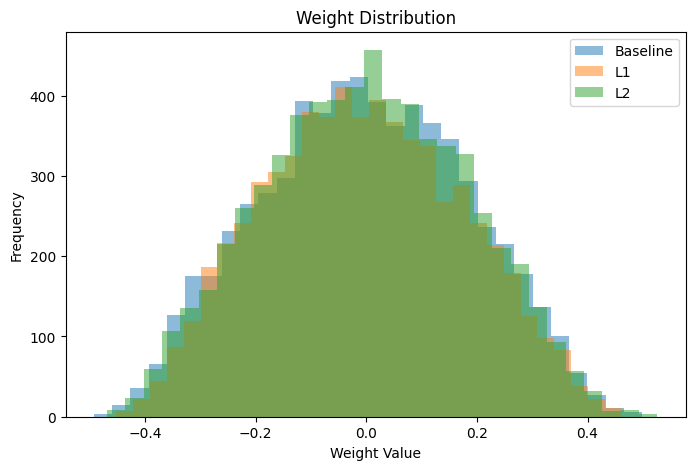

In [16]:
weights_base = baseline.layers[0].get_weights()[0].flatten()
weights_l1 = model_l1.layers[0].get_weights()[0].flatten()
weights_l2 = model_l2.layers[0].get_weights()[0].flatten()

plt.figure(figsize=(8,5))
plt.hist(weights_base, bins=30, alpha=0.5, label="Baseline")
plt.hist(weights_l1, bins=30, alpha=0.5, label="L1")
plt.hist(weights_l2, bins=30, alpha=0.5, label="L2")
plt.legend()
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()


In [17]:
threshold = 0.001

print("Baseline:",
      np.sum(np.abs(weights_base) < threshold))
print("L1:",      np.sum(np.abs(weights_l1) < threshold))
print("L2:",      np.sum(np.abs(weights_l2) < threshold))


Baseline: 19
L1: 39
L2: 27


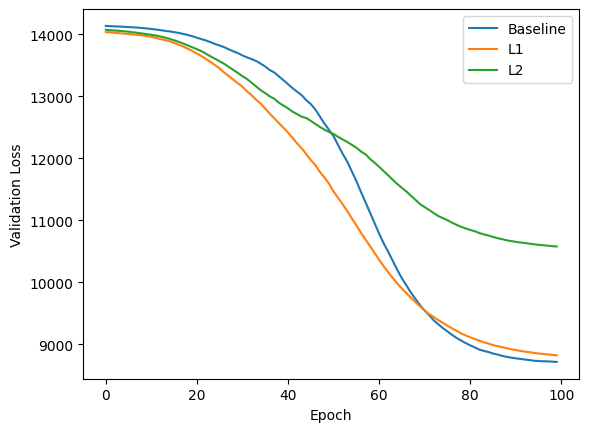

In [18]:
plt.plot(history_base.history['val_loss'], label="Baseline")
plt.plot(history_l1.history['val_loss'], label="L1")
plt.plot(history_l2.history['val_loss'], label="L2")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()
